In [1]:
# !pip install python-vlc

In [2]:
# карта ладони MediaPipe

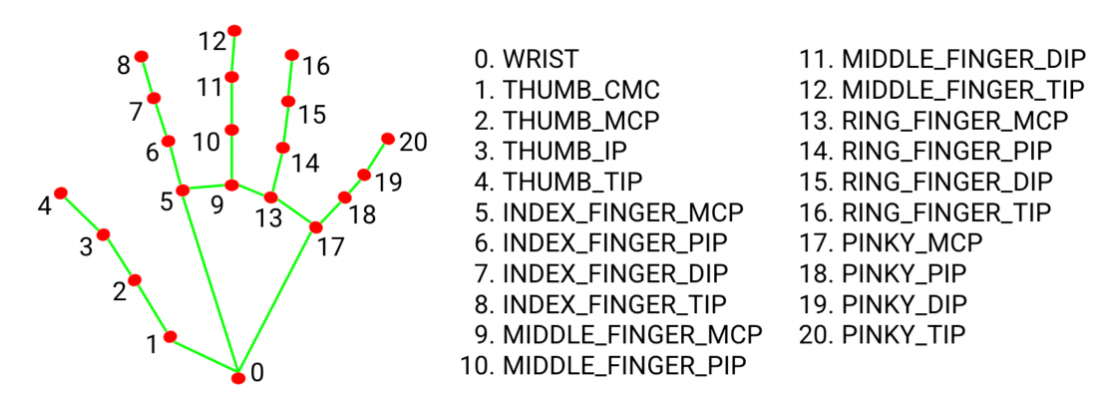

In [3]:
from IPython.display import display, Image
import cv2
import mediapipe as mp
import numpy as np
import vlc

2023-12-25 14:01:30.776189: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-25 14:01:31.192316: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-25 14:01:31.195133: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-12-25 14:01:32.350183: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
# модуль распознавания жестов для медиаплеера
class PalmReader():

    # инициализация модуля распознавания жестов
    def __init__(self): 
        # набор команд
        self._commands = { 
            'none':0, # жест не обнаружен
            'stop':1, # остановить проигрыватель
            'play':2, # запустить проигрыватель
            'volume':3, # выставить громкость
        }
        # индексы кончиков пальцев на карте ладони MediaPipe
        self._finger_tips_id = [4,8,12,16,20]
        # индексы основания пальцев на карте ладони MediaPipe
        self._finger_base_id = [1,6,10,14,18]    
        # модуль построения карты ладони MediaPipe
        self._hands = mp.solutions.hands.Hands()

    @property
    def commands(self): # выдаём список комманд по запросу
        return self._commands
    
    # распознаём картинку
    def read(self,frame): 
        img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) # конвертируем цветовую схему картинки
        results = self._hands.process(img) # строим карту ладони по картинке
        if results.multi_hand_landmarks is None: 
            # если ладонь не обнаружена, то идём за новым кадром
            return frame, self._commands['none'],0
        hand_lms = results.multi_hand_landmarks[-1] # выбираем правую руку
        mp.solutions.drawing_utils.draw_landmarks(  # рисуем курту руки
            img, hand_lms, mp.solutions.hands.HAND_CONNECTIONS
        )
        cmd,value,img = self._check_palm(hand_lms,img) # считываем жест
        return ( # возвращаем результат
            cv2.cvtColor(img,cv2.COLOR_BGR2RGB), # картинка с нарисованными метками 
            cmd, # распознаный жест / команда
            value, # дополнительные параметры команды
        ) 
    
    # считываем жест
    def _check_palm(self,hand_lms,img):
        cmd_pos = (40,40) # положение метки комманты на картинке
        h, w, _ = img.shape # размер картинки
        if not self._check_right(hand_lms): # проверяем, что рука правая
            return  self._commands['none'],0,img # иначе переходим за следующим кадром
        
        # размер ладони и коэфициент масштабирования относительно всей картинки
        img,bbox,ratio = self._get_palm_bbox(hand_lms,img) 
        
        # проверяем состояния пальцев ладони
        fingers_up = [  self._check_finger(n,hand_lms) for n in range(5) ]
                
        if all(fingers_up[1:]): # все пальцы подняты, открытая ладонь
            # распознан жест "стоп"
            cv2.putText(img,'STOP',cmd_pos,cv2.FONT_HERSHEY_PLAIN, 2, (255,0, 0,),2)
            return self._commands['stop'],0,img

        
        if all(fingers_up[:2]): # подняты большой и указательный пальцы
            # распознан жест - "изменить уровень громкости"
            
            # определить расстояние между конциками большого и указательного пальца
            (x0,y0),(x1,y1),d = self._dist_fingers(hand_lms)
            
            # расчитать уровень громкости по растоянию и коэффициенту масштабирования
            d_volume = int((d/ratio)*500.)
            d_volume = min(100,max(10,d_volume))
            
            # отобразить на картинке результат расчётов
            cv2.line(img, (int(x0*w),int(y0*h)),(int(x1*w),int(y1*h)),(255,0,255),1)
            cv2.putText(img,f'VOLUME: {d_volume}' ,cmd_pos,cv2.FONT_HERSHEY_PLAIN, 2,(255,0,255),2)
            
            if self._check_volume_set(hand_lms): # мизинец в сочетании с большим и указательным пальцами
                # распознан жест - "установить выбранную громкость"
                # отобразить на картинке признак изменения грамкости
                cv2.putText(img,f'SET' ,(cmd_pos[0]+250,cmd_pos[1]),cv2.FONT_HERSHEY_PLAIN, 2,(255,255,0),2)
                return self._commands['volume'],d_volume,img
            
            # громкость пока не выбрана, ждём команду SET 
            return self._commands['none'],0,img # переходим к следующему кадру

        if (not any(fingers_up[1:4])) and fingers_up[4]:  # поднят только мизинец
            # распознан жест - "запустить проигрыватель"
            # отобразить на картинке символ PLAY
            cv2.putText(img,'PLAY',cmd_pos,cv2.FONT_HERSHEY_PLAIN, 2, (0, 255, 0,),2)
            return self._commands['play'],0,img # переходим к следующему кадру

        # жесты не обнаружены
        return self._commands['none'],0,img # переходим к следующему кадру

    # размер ладони и коэфициент масштабирования относительно всей картинки
    def _get_palm_bbox(self,hand_lms,img):
        h, w, _ = img.shape # размер картинки
        # координаты всех меток обнаруженых на картинке
        coo = np.array([ (lm.x*w, lm.y*h) for lm in hand_lms.landmark ]).astype(int)
        # координаты углов рамки ладони
        p_min,p_max = coo.min(axis=0),coo.max(axis=0)
        d = p_max-p_min # размеры (длины сторон) рамки
        ratio = d/np.array([h,w]) # отношение размеров рамки к размеру всей картинки
        #cv2.rectangle(img,tuple(p_min-20),tuple(p_max+20), (0,255,0), 2)
        #rx,ry = ratio
        #pos = tuple(p_min-(20,25))
        #cv2.putText(img,f'{rx:.2},{ry:.2}',pos,cv2.FONT_HERSHEY_PLAIN, 1, (255,255,0,),1)
        return (
            img, # картинка с метками
            (p_min,p_max), # координаты углов рамки ладони
            max(ratio) # коэффициент масштабирования
        )

    # проверяем состояния пальцев ладони
    def _check_finger(self,n,hand_lms):     
        finger_tip = hand_lms.landmark[self._finger_tips_id[n]] # координаты кончикa пальца n
        finger_base = hand_lms.landmark[self._finger_base_id[n]] # координаты основания
        return finger_tip.y<finger_base.y # кончик выше основания, палец поднят

    # расстояние между кончиком указательного и большого пальцев
    def _dist_fingers(self,hand_lms):
        finger_tip_0 = hand_lms.landmark[self._finger_tips_id[0]] # координаты кончикa большого пальца 
        x0,y0 = finger_tip_0.x,finger_tip_0.y
        finger_tip_1 = hand_lms.landmark[self._finger_tips_id[1]] # координаты кончикa указательного пальца 
        x1,y1 = finger_tip_1.x,finger_tip_1.y
        d = (x0-x1)**2+(y0-y1)**2 # считаем расстояние
        return (
            (x0,y0), # координаты кончикa большого пальца 
            (x1,y1), # координаты кончикa указательного пальца 
            d, # расстояние
        )

    # проверка состояния мизинца
    def _check_volume_set(self,hand_lms):
        finger_tip_5 = hand_lms.landmark[self._finger_tips_id[4]] # координаты кончикa мизинца
        finger_base_4 = hand_lms.landmark[self._finger_base_id[4]] # координаты основания безымянного
        return finger_tip_5.x>finger_base_4.x # мизинец поднят и отведён в сторону

    # проверка правой руки
    def _check_right(self,hand_lms): 
        finger_base_5 = hand_lms.landmark[self._finger_base_id[4]] # координаты основания мизинца
        finger_base_1 = hand_lms.landmark[self._finger_base_id[0]] # координаты основания большого
        return finger_base_5.x>finger_base_1.x # большой палец слева от мизинца

In [5]:
# открываем медиаплеер
file_mp3 = 'data/kate_lindsey-susannetta_sei_tu_non_so_piu.mp3'
player = vlc.MediaPlayer(file_mp3)

# открываем камеру
cap = cv2.VideoCapture(0)
assert cap.isOpened(), 'error camera not opened'

# параметры картинки
width, height = cap.get(cv2.CAP_PROP_FRAME_WIDTH), cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

# будем записывать видео файл
fourcc = cv2.VideoWriter_fourcc(*'XVID') #codec
out = cv2.VideoWriter( 'output2.avi', fourcc, 20.0, (int(width), int(height))  )

# будем отображать картинку
display_handle = display(None,display_id=True)

palm = PalmReader() # распознаватель жестов

try:
    while True: # запускаем основной цикл
        _, frame = cap.read() # считать кадр
        frame = cv2.flip(frame, 1) # повернуть кадр
        img, cmd, value = palm.read(frame) # распознать жест
        
        if cmd ==  palm.commands['play']: # обнаружен жест play
            # запускаем проигрыватель
            if player.get_state()!=vlc.State.Playing: player.play()
                
        elif cmd == palm.commands['stop']: # обнаружен жест stop
            # останавливаем проигрыватель
            if player.get_state()!=vlc.State.Paused: player.pause()
                
        elif cmd == palm.commands['volume']: # обнаружен жест "установить громкость"
            # изменяем громкость
            player.audio_set_volume(value)            
        
        out.write(img) # пишем кадр в файл
        
        # отображаем картинку на дисплей
        display_handle.update(Image(data=cv2.imencode('.jpeg',img)[1].tobytes()))
        
except KeyboardInterrupt: # перехват прерывания с клавиатуры
    pass
    
except Exception as e: # перехват ошибок
    print(e)
    
finally: # закрываем все устройства и завершаем работу
    display_handle.update(None)
    cap.release()
    out.release()
    player.stop()
    display('close webcam')

None

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


'close webcam'